# Data Drift Analysis

Demonstrating drift detection using KS test, PSI, and Wasserstein distance.

The core MLOps problem: models degrade silently when production data
distribution shifts away from training data. Drift detection catches this.

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.ingestion import DataIngestion
from src.data.splitter import DataSplitter
from src.monitoring.drift_detector import DriftDetector
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ingestion        = DataIngestion()
df               = ingestion.load()
splitter         = DataSplitter()
train, val, test = splitter.split(df)

detector = DriftDetector()
print("Drift detector ready")
print(f"Drift threshold: {detector.drift_threshold}")

2026-07-01 13:16:32 | INFO | src.data.ingestion | Using cached dataset
2026-07-01 13:16:32 | INFO | src.data.ingestion | Dataset loaded
2026-07-01 13:16:32 | INFO | src.data.splitter | Data split complete
2026-07-01 13:16:32 | INFO | src.data.splitter | Class ratio in train
2026-07-01 13:16:32 | INFO | src.data.splitter | Class ratio in val
2026-07-01 13:16:32 | INFO | src.data.splitter | Class ratio in test
Drift detector ready
Drift threshold: 0.1


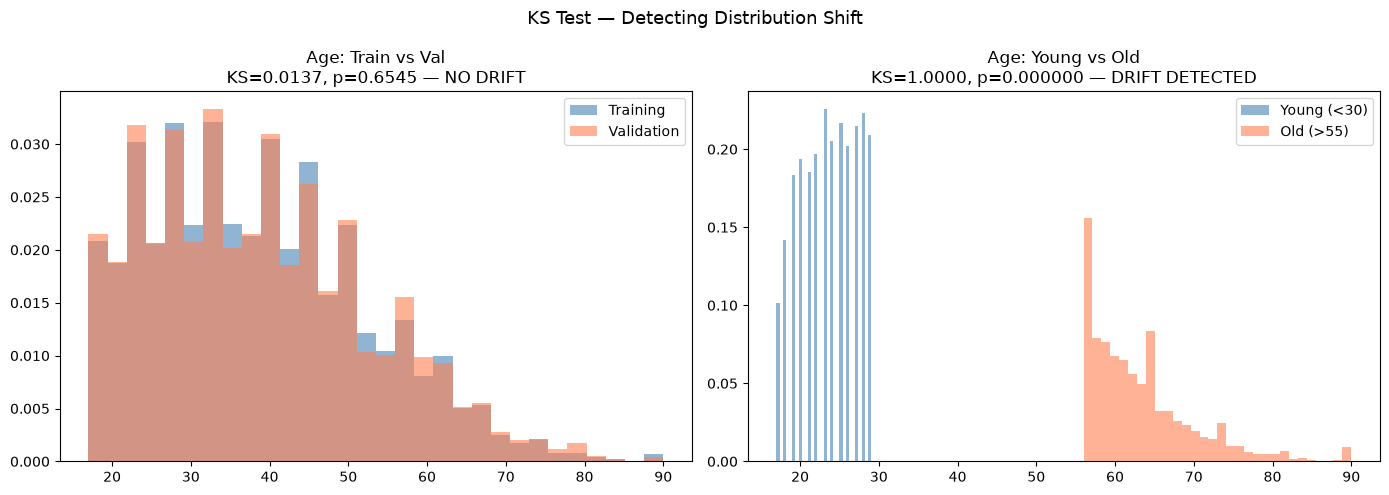

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("KS Test — Detecting Distribution Shift", fontsize=13)

# No drift scenario
ref  = train["age"].dropna().values
prod = val["age"].dropna().values

ks_stat, p_val = stats.ks_2samp(ref, prod)
ax = axes[0]
ax.hist(ref,  bins=30, alpha=0.6, density=True, label="Training", color="steelblue")
ax.hist(prod, bins=30, alpha=0.6, density=True, label="Validation", color="coral")
ax.set_title(f"Age: Train vs Val\nKS={ks_stat:.4f}, p={p_val:.4f} — NO DRIFT")
ax.legend()

# Drift scenario
young = df[df["age"] < 30]["age"].dropna().values
old   = df[df["age"] > 55]["age"].dropna().values

ks_stat2, p_val2 = stats.ks_2samp(young, old)
ax2 = axes[1]
ax2.hist(young, bins=30, alpha=0.6, density=True, label="Young (<30)", color="steelblue")
ax2.hist(old,   bins=30, alpha=0.6, density=True, label="Old (>55)", color="coral")
ax2.set_title(f"Age: Young vs Old\nKS={ks_stat2:.4f}, p={p_val2:.6f} — DRIFT DETECTED")
ax2.legend()

plt.tight_layout()
plt.savefig("../data/ks_test_visualization.png", dpi=150)
plt.show()

In [3]:
young_df = df[df["age"] < 30].copy()
old_df   = df[df["age"] > 55].copy()

report = detector.detect_drift(train, old_df)

print(f"Overall drift: {report['overall_drift_detected']}")
print(f"Drift rate:    {report['drift_rate']:.2%}")
print(f"Should retrain: {report['should_retrain']}")
print(f"\nDrifted features ({len(report['drifted_features'])}):")
for feat in report["drifted_features"]:
    feat_result = report["feature_results"][feat]
    if feat_result["type"] == "numerical":
        ks = feat_result["ks_test"]
        print(f"  {feat}: KS={ks['ks_statistic']:.4f}, p={ks['p_value']:.4f}")
    else:
        psi = feat_result["psi"]
        print(f"  {feat}: PSI={psi['psi']:.4f}")

2026-07-01 13:16:53 | INFO | src.monitoring.drift_detector | Running drift detection
2026-07-01 13:16:53 | WARNING | src.monitoring.drift_detector | DRIFT DETECTED
Overall drift: True
Drift rate:    50.00%
Should retrain: True

Drifted features (7):
  age: KS=0.8762, p=0.0000
  fnlwgt: KS=0.0668, p=0.0000
  education_num: KS=0.0930, p=0.0000
  capital_gain: KS=0.0443, p=0.0000
  hours_per_week: KS=0.1182, p=0.0000
  marital_status: PSI=0.6839
  relationship: PSI=0.4821


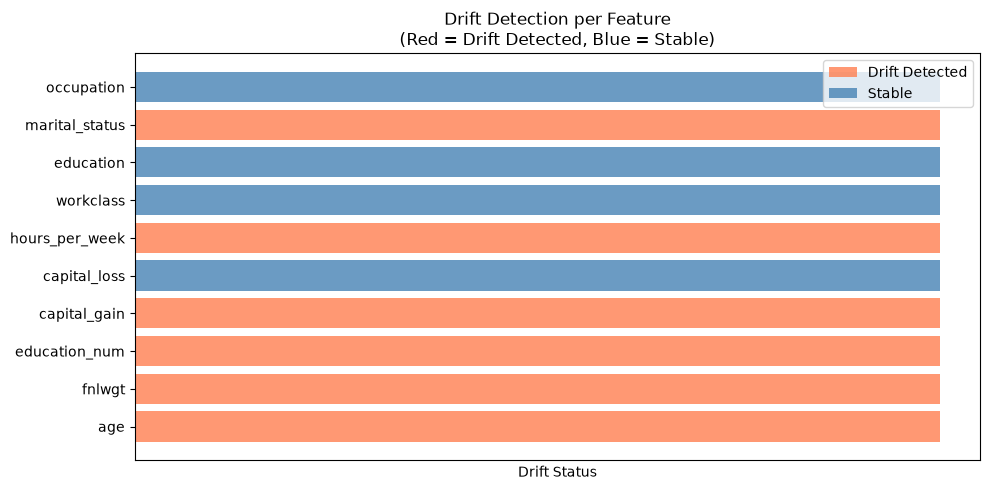

In [4]:
features = list(report["feature_results"].keys())[:10]
drift_detected = [report["feature_results"][f]["drift_detected"] for f in features]
colors = ["coral" if d else "steelblue" for d in drift_detected]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(features, [1]*len(features), color=colors, alpha=0.8)
ax.set_xlabel("Drift Status")
ax.set_title("Drift Detection per Feature\n(Red = Drift Detected, Blue = Stable)")
ax.set_xticks([])

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='coral', alpha=0.8, label='Drift Detected'),
    Patch(facecolor='steelblue', alpha=0.8, label='Stable'),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig("../data/drift_per_feature.png", dpi=150)
plt.show()

## The Retraining Decision

When drift is detected the monitoring DAG:
1. Logs the drift report with affected features
2. Triggers the retraining DAG automatically
3. The retraining DAG trains fresh models
4. A/B comparison decides whether to promote the new model

**Key insight:** drift detection alone doesn't mean retrain immediately.
The A/B gate ensures the new model is actually better before promotion.
This prevents unnecessary retraining and model churn.

**PSI thresholds used in production:**
- PSI < 0.10: no action needed
- PSI 0.10-0.20: monitor more closely
- PSI > 0.20: trigger investigation and potential retraining